In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft, istft, resample_poly
from IPython.display import Audio, display

FILENAME = "2_read_lrs.wav"        # ← 改成你的文件名

sr_in, raw = wavfile.read(FILENAME)
print(f"原始: 采样率 {sr_in} Hz, dtype={raw.dtype}, shape={raw.shape}")

# --- 转成 float ---
if raw.dtype == np.int16:
    x = raw.astype(np.float64) / 32768.0
elif raw.dtype == np.int32:
    x = raw.astype(np.float64) / 2147483648.0
else:
    x = raw.astype(np.float64)

# --- 多声道转单声道 ---
if x.ndim > 1:
    print(f"  {x.shape[1]} 声道 -> 取平均转单声道")
    x = x.mean(axis=1)

# --- 重采样到 16 kHz ---
sr = 16000
if sr_in != sr:
    g = np.gcd(int(sr_in), sr)
    x = resample_poly(x, sr // g, sr_in // g)
    print(f"  重采样 {sr_in} -> {sr} Hz")

# --- 去直流 + 归一化 ---
x = x - np.mean(x)                       # 去直流偏置
x = x / np.max(np.abs(x)) * 0.5

t = np.arange(len(x)) / sr
print(f"\n最终: {len(x)/sr:.2f} 秒, {sr} Hz, 峰值 {np.max(np.abs(x)):.2f}")
display(Audio(x, rate=sr))

原始: 采样率 16000 Hz, dtype=float32, shape=(203093,)

最终: 12.69 秒, 16000 Hz, 峰值 0.50


C:\Users\光\AppData\Local\Temp\ipykernel_33204\3895938548.py:9: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr_in, raw = wavfile.read(FILENAME)


① 削波样点数: 0  正常
② 开头 1.2 秒内的安静帧数: 117/120  正常
③ 本底噪声 -57.7 dB, 语音 -27.6 dB, 原始 SNR ≈ 30.2 dB


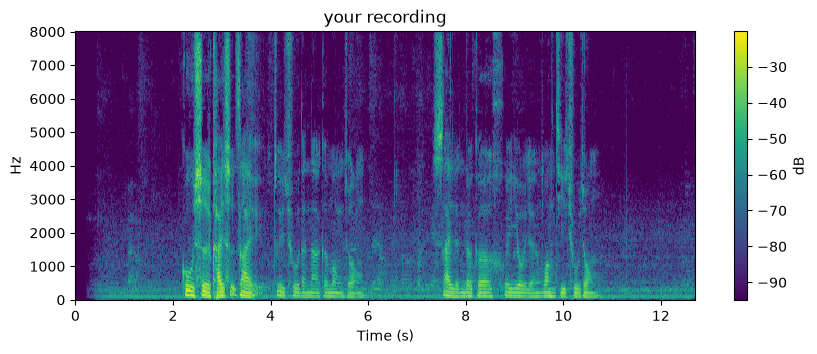

In [3]:
# ① 有没有削波
clipped = np.sum(np.abs(raw) >= 32700) if raw.dtype == np.int16 else 0
print(f"① 削波样点数: {clipped}  {'⚠️ 录音时音量过大' if clipped > 10 else '正常'}")

# ② 开头有没有足够的静音
f, tt, X = stft(x, sr, nperseg=400, noverlap=240)
frame_e = 10*np.log10(np.sum(np.abs(X)**2, axis=0) + 1e-12)
n_quiet = np.sum(frame_e[:120] < frame_e.max() - 25)
print(f"② 开头 1.2 秒内的安静帧数: {n_quiet}/120  {'正常' if n_quiet > 60 else '⚠️ 静音不够'}")

# ③ 本底噪声水平（你录音环境的固有噪声）
noise_floor = 20*np.log10(np.std(x[:int(0.5*sr)]) + 1e-12)
signal_level = 20*np.log10(np.std(x[int(1.5*sr):]) + 1e-12)
print(f"③ 本底噪声 {noise_floor:.1f} dB, 语音 {signal_level:.1f} dB, "
      f"原始 SNR ≈ {signal_level - noise_floor:.1f} dB")

# 语谱图
plt.figure(figsize=(10, 3.5))
S = 20*np.log10(np.abs(X) + 1e-8)
plt.pcolormesh(tt, f, S, shading="auto", vmin=S.max()-75, vmax=S.max())
plt.ylabel("Hz"); plt.xlabel("Time (s)"); plt.colorbar(label="dB")
plt.title("your recording"); plt.show()

估计基频 ≈ 109 Hz


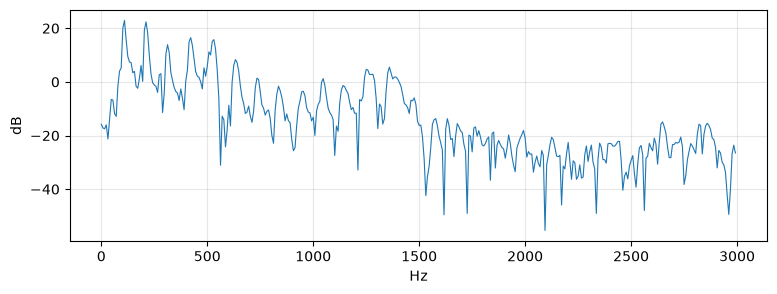

In [4]:
seg = x[int(len(x)*0.4):int(len(x)*0.4)+2048]      # 取中间一段
sp = np.abs(np.fft.rfft(seg * np.hanning(len(seg))))
fr = np.fft.rfftfreq(len(seg), 1/sr)
m = (fr > 60) & (fr < 400)
print(f"估计基频 ≈ {fr[m][np.argmax(sp[m])]:.0f} Hz")

plt.figure(figsize=(9,3))
plt.plot(fr[fr<3000], 20*np.log10(sp[fr<3000]+1e-8), lw=.8)
plt.xlabel("Hz"); plt.ylabel("dB"); plt.grid(alpha=.3); plt.show()

In [5]:
# ===== 加噪声 =====
rng = np.random.default_rng(0)

def colored_noise(beta, n, seed=0):
    r = np.random.default_rng(seed)
    s = r.standard_normal(n//2+1) + 1j*r.standard_normal(n//2+1)
    fq = np.arange(len(s)).astype(float); fq[0] = 1
    y = np.fft.irfft(s / fq**(beta/2), n=n)
    return y / (np.std(y) + 1e-9)

NOISE_TYPE = 1.0        # 0=白噪 1=粉噪 2=布朗噪
SNR_DB     = 5.0        # 目标信噪比

nz = colored_noise(NOISE_TYPE, len(x), 1)
nz = nz * np.sqrt(np.mean(x**2) / (np.mean(nz**2) * 10**(SNR_DB/10)))
noisy = x + nz

print(f"输入 SNR = {10*np.log10(np.mean(x**2)/np.mean(nz**2)):.2f} dB")
display(Audio(noisy, rate=sr))

输入 SNR = 5.00 dB


In [6]:
def estimate_noise_minstat(power, win=60, alpha_s=0.7, bias=1.0):
    n_freq, n_frames = power.shape
    noise_est = np.zeros_like(power)
    S   = power[:, 0].copy()      # 平滑后的功率谱。切片要 .copy()
    buf = []                      # 滑动窗历史

    for i in range(n_frames):
        S = alpha_s * S + (1 - alpha_s) * power[:, i]        # ① 时间平滑
        buf.append(S.copy())
        if len(buf) > win:
            buf.pop(0)                                       # ② 只留最近 win 帧
        noise_est[:, i] = bias * np.min(np.stack(buf), axis=0)   # ③ 取最小 x 补偿

    return noise_est

In [7]:
from scipy.special import exp1, i0e, i1e

f, tt, Xn = stft(noisy, sr, nperseg=400, noverlap=240)
power = np.abs(Xn)**2
C = stft(x,  sr, nperseg=400, noverlap=240)[2]
N = stft(nz, sr, nperseg=400, noverlap=240)[2]

def rec(G): 
    return istft(Xn*G, sr, nperseg=400, noverlap=240)[1][:len(x)]
def snr_of(e):
    return 10*np.log10(np.mean(x**2)/np.mean((e[:len(x)]-x)**2))

# --- 噪声估计（复用你的） ---
noise_est = estimate_noise_minstat(power, win=60, alpha_s=0.7, bias=1.0)

# --- 五种增益函数 ---
def g_specsub(xi, gam): return np.maximum(1 - 1/np.maximum(gam,1e-9), 0.1)
def g_wiener(xi, gam):  return xi/(1+xi)
def g_stsa(xi, gam):
    v = xi/(1+xi)*gam; vs = np.minimum(v, 50.0)
    b = (1+vs)*i0e(vs/2) + vs*i1e(vs/2)
    return np.where(v<50, np.sqrt(np.pi*vs)/(2*np.maximum(gam,1e-12))*b, xi/(1+xi))
def g_lsa(xi, gam):
    v = np.clip(xi/(1+xi)*gam, 1e-8, 500)
    return xi/(1+xi)*np.exp(0.5*exp1(v))

def run(gain_fn, omlsa=False, alpha=0.98, gmin=0.1, q=0.3):
    G = np.zeros_like(power); Gp = gp = None
    for i in range(power.shape[1]):
        gam = power[:,i]/np.maximum(noise_est[:,i], 1e-12)
        xi  = np.maximum(gam-1,0) if Gp is None else alpha*Gp**2*gp+(1-alpha)*np.maximum(gam-1,0)
        xi  = np.maximum(xi, 1e-6)
        g   = gain_fn(xi, gam)
        if omlsa:
            v = np.clip(xi/(1+xi)*gam, 1e-8, 500)
            p = 1.0/(1.0 + (q/(1-q))*(1+xi)*np.exp(-v))
            g = g**p * gmin**(1-p)
        g = np.clip(g, gmin, 1.0)
        G[:,i] = g; Gp, gp = g, gam
    return rec(G), G

results = {}
results["noisy"]      = (noisy, None)
results["谱减法"]      = run(g_specsub)
results["维纳"]        = run(g_wiener)
results["MMSE-STSA"]  = run(g_stsa)
results["MMSE-LSA"]   = run(g_lsa)
results["OM-LSA"]     = run(g_lsa, omlsa=True)

S2, N2 = np.abs(C)**2, np.abs(N)**2
IRM = np.sqrt(S2/(S2+N2+1e-12))
results["IRM 上限"]    = (rec(IRM), IRM)

print(f"\n{'方法':14s}{'SNR(dB)':>9s}")
for k, (y_, _) in results.items():
    print(f"{k:14s}{snr_of(y_):9.2f}")


方法              SNR(dB)
noisy              5.00
谱减法                6.58
维纳                 8.41
MMSE-STSA          7.91
MMSE-LSA           8.28
OM-LSA             8.46
IRM 上限            13.93


In [8]:
for name, (y_, _) in results.items():
    print(name)
    display(Audio(np.clip(y_, -1, 0.99997), rate=sr))

noisy


谱减法


维纳


MMSE-STSA


MMSE-LSA


OM-LSA


IRM 上限


In [9]:
print(f"{'方法':14s}{'SNR':>8s}{'NR(dB)':>9s}{'SD(dB)':>9s}{'与IRM差':>9s}")
for name, (y_, G_) in results.items():
    if G_ is None: 
        print(f"{name:14s}{snr_of(y_):8.2f}{0.0:9.2f}{0.0:9.2f}")
        continue
    resid  = rec(G_ * N)          # 噪声分量单独走同一组增益
    kept   = rec(G_ * C)          # 语音分量单独走同一组增益
    nr = 10*np.log10(np.mean(nz**2)  / (np.mean(resid**2) + 1e-12))
    sd = 10*np.log10(np.mean(x**2)   / (np.mean(kept**2)  + 1e-12))
    print(f"{name:14s}{snr_of(y_):8.2f}{nr:9.2f}{sd:9.2f}{np.mean(np.abs(G_-IRM)):9.3f}")

方法                 SNR   NR(dB)   SD(dB)    与IRM差
noisy             5.00     0.00     0.00
谱减法               6.58    41.44    37.25    0.386
维纳                8.41    41.77    37.36    0.203
MMSE-STSA         7.91    41.79    37.36    0.337
MMSE-LSA          8.28    41.83    37.37    0.239
OM-LSA            8.46    41.88    37.36    0.196
IRM 上限           13.93    53.44    37.20    0.000


C:\Users\光\AppData\Local\Temp\ipykernel_36588\611150717.py:11: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\光\AppData\Local\Temp\ipykernel_36588\611150717.py:11: UserWarning: Glyph 20943 (\N{CJK UNIFIED IDEOGRAPH-51CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\光\AppData\Local\Temp\ipykernel_36588\611150717.py:11: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\光\AppData\Local\Temp\ipykernel_36588\611150717.py:11: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\光\AppData\Local\Temp\ipykernel_36588\611150717.py:11: UserWarning: Glyph 38480 (\N{CJK UNIFIED IDEOGRAPH-9650}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


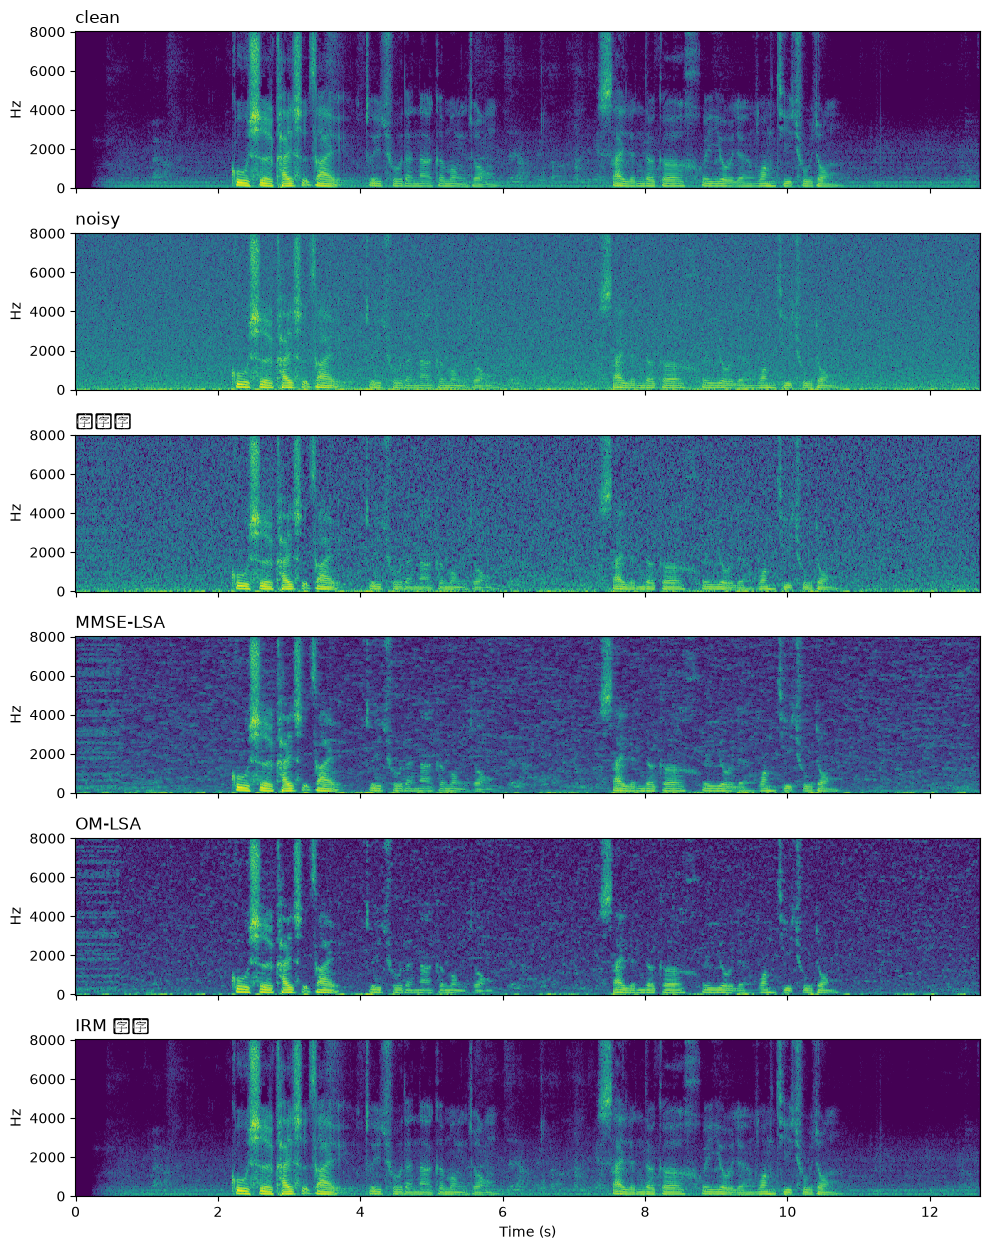

In [12]:
show = ["noisy", "谱减法", "MMSE-LSA", "OM-LSA", "IRM 上限"]
fig, axes = plt.subplots(len(show)+1, 1, figsize=(10, 2.1*(len(show)+1)), sharex=True)
Sc = 20*np.log10(np.abs(C)+1e-8); vmax = Sc.max()
axes[0].pcolormesh(tt, f, Sc, shading="auto", vmin=vmax-75, vmax=vmax)
axes[0].set_title("clean", loc="left"); axes[0].set_ylabel("Hz")
for ax, name in zip(axes[1:], show):
    Sx = 20*np.log10(np.abs(stft(results[name][0], sr, nperseg=400, noverlap=240)[2])+1e-8)
    ax.pcolormesh(tt, f, Sx, shading="auto", vmin=vmax-75, vmax=vmax)
    ax.set_title(name, loc="left"); ax.set_ylabel("Hz")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()